In [17]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import cv2
from google.colab.patches import cv2_imshow

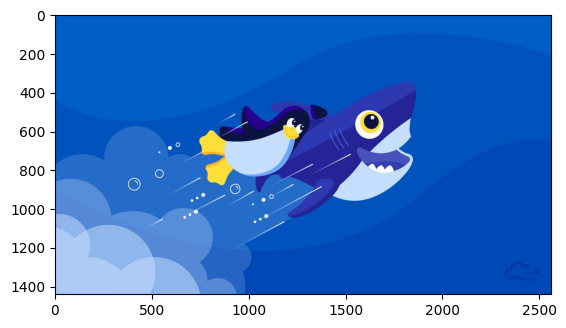

In [11]:
img_path = "/content/penguin.jpg"
penguin = mpimg.imread(img_path)
plt.imshow(penguin)

In [12]:
penguin

array([[[  1,  94, 198],
        [  1,  94, 198],
        [  1,  94, 198],
        ...,
        [  1,  94, 198],
        [  1,  94, 198],
        [  1,  94, 198]],

       [[  1,  94, 198],
        [  1,  94, 198],
        [  1,  94, 198],
        ...,
        [  1,  94, 198],
        [  1,  94, 198],
        [  1,  94, 198]],

       [[  1,  94, 198],
        [  1,  94, 198],
        [  1,  94, 198],
        ...,
        [  1,  94, 198],
        [  1,  94, 198],
        [  1,  94, 198]],

       ...,

       [[167, 200, 245],
        [167, 200, 245],
        [167, 200, 245],
        ...,
        [  0,  72, 182],
        [  0,  72, 182],
        [  0,  72, 182]],

       [[167, 200, 245],
        [167, 200, 245],
        [167, 200, 245],
        ...,
        [  0,  72, 182],
        [  0,  72, 182],
        [  0,  72, 182]],

       [[167, 200, 245],
        [167, 200, 245],
        [167, 200, 245],
        ...,
        [  0,  72, 182],
        [  0,  72, 182],
        [  0,  72, 182]]

In [13]:
penguin.shape

(1440, 2560, 3)

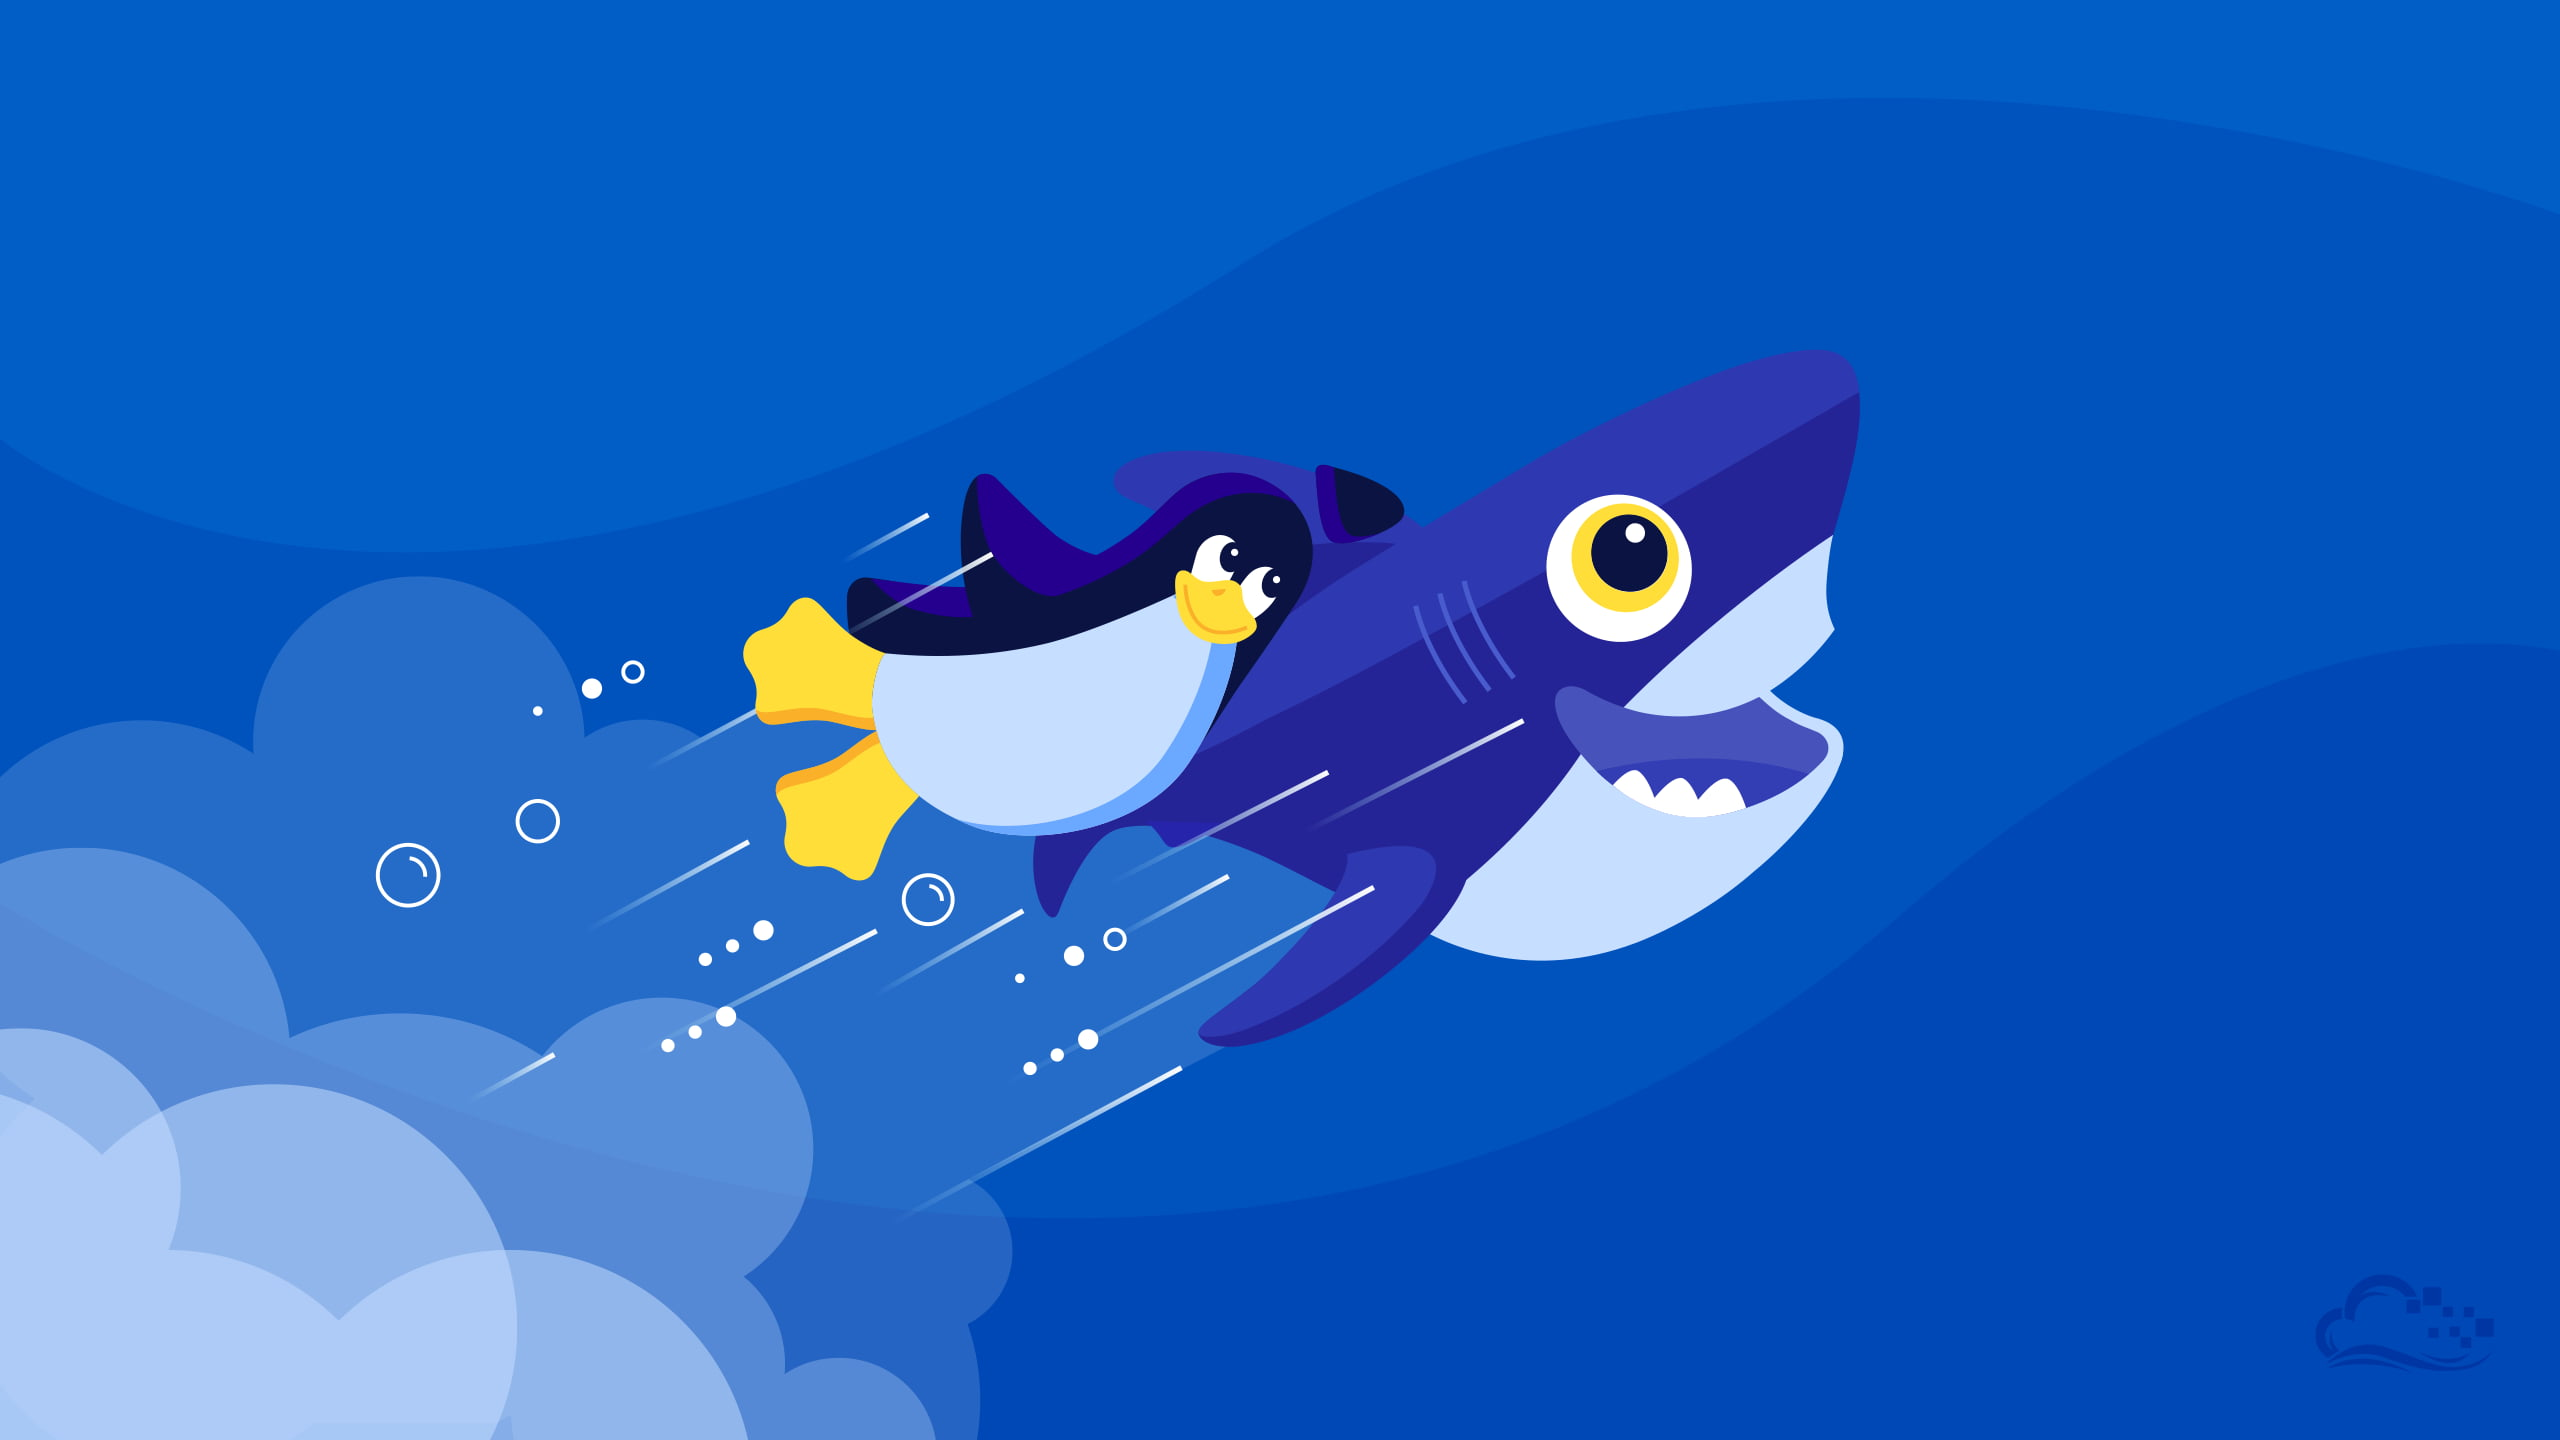

In [18]:
penguin_cv2 = cv2.imread(img_path)
cv2_imshow(penguin_cv2)

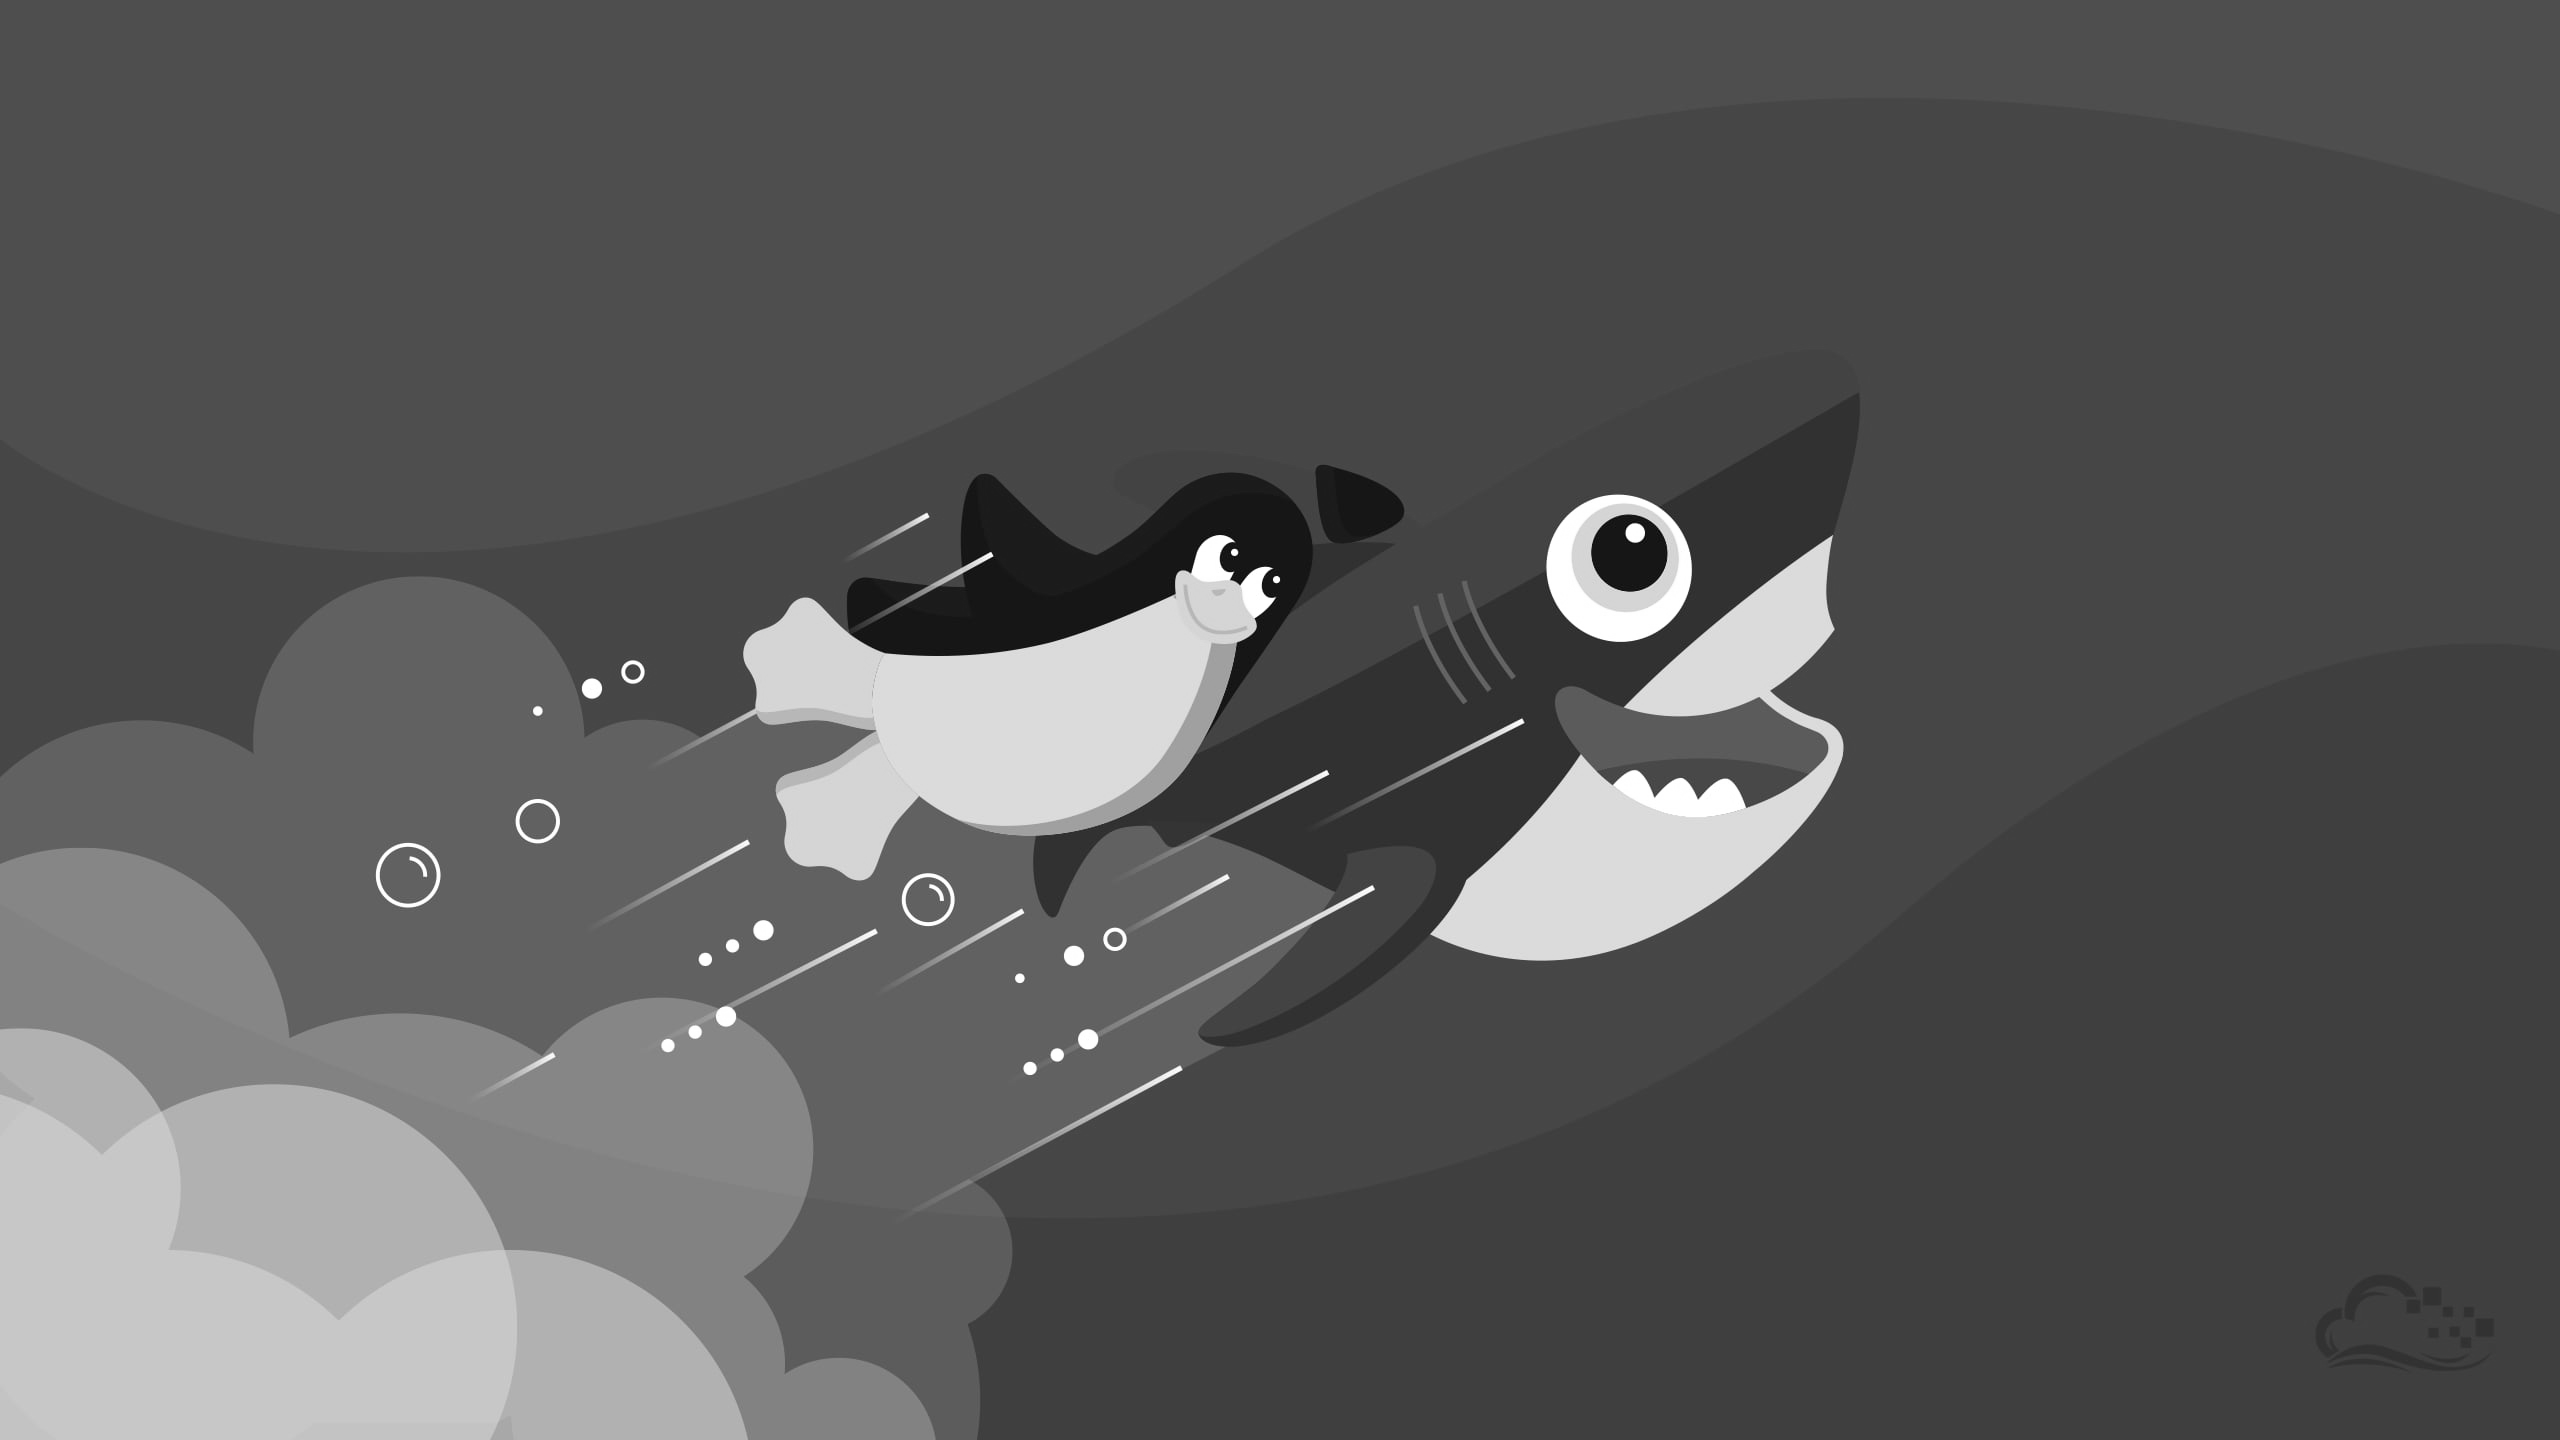

In [20]:
penguin_bgr_gray = cv2.cvtColor(penguin_cv2, cv2.COLOR_BGR2GRAY)
cv2_imshow(penguin_bgr_gray)

In [21]:
penguin_bgr_gray.shape

(1440, 2560)

In [22]:
penguin_bgr_gray.min()

np.uint8(3)

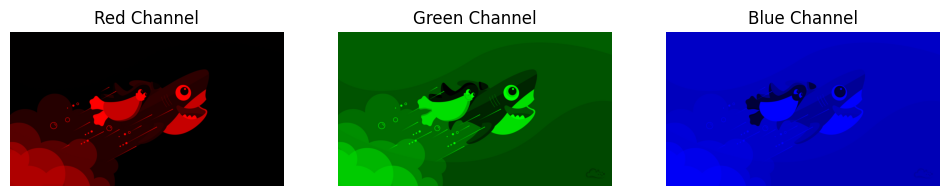

In [24]:
# 2. Split into Blue, Green, and Red channels (OpenCV order!)
b, g, r = cv2.split(penguin_cv2)

# Create a blank black canvas of the same size to mask unwanted channels
blank = np.zeros(penguin_cv2.shape[:2], dtype="uint8")

# 3. Reconstruct pure Red, Green, and Blue images
# Remember OpenCV expects BGR format for merging
red_img = cv2.merge([blank, blank, r])    # Only Red has data
green_img = cv2.merge([blank, g, blank])  # Only Green has data
blue_img = cv2.merge([b, blank, blank])   # Only Blue has data

# 4. Convert to RGB for Matplotlib display
red_rgb = cv2.cvtColor(red_img, cv2.COLOR_BGR2RGB)
green_rgb = cv2.cvtColor(green_img, cv2.COLOR_BGR2RGB)
blue_rgb = cv2.cvtColor(blue_img, cv2.COLOR_BGR2RGB)

# 5. Plot them side-by-side
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.title("Red Channel")
plt.imshow(red_rgb)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Green Channel")
plt.imshow(green_rgb)
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Blue Channel")
plt.imshow(blue_rgb)
plt.axis('off')

plt.show()

In [25]:
sobel = np.array([
    [1,0,-1],
    [2,0,-2],
    [1,0,-1]
])
sobel

array([[ 1,  0, -1],
       [ 2,  0, -2],
       [ 1,  0, -1]])

In [29]:
def apply_sobel_scratch(image, kernel):
    """
    Applies a custom Sobel kernel to an image using manual convolution.
    """
    # 1. Load the image in grayscale
    img = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    if img is None:
        raise ValueError("Image not found. Check your file path!")

    img_height, img_width = img.shape
    k_height, k_width = kernel.shape

    # 2. Manual Padding (Zero Padding) to handle the image borders
    # For a 3x3 kernel, pad_h and pad_w will be 1 pixel on all sides
    pad_h = k_height // 2
    pad_w = k_width // 2
    padded_img = np.pad(img, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant', constant_values=0)

    # Create an empty array to hold our output
    output = np.zeros_like(img, dtype=np.float32)

    # 3. Perform Convolution (Sliding the kernel)
    for i in range(img_height):
        for j in range(img_width):
            # Extract the region of interest (ROI) matching the kernel size
            roi = padded_img[i : i + k_height, j : j + k_width]

            # Element-wise multiply and sum the results
            output[i, j] = np.sum(roi * kernel)

    # 4. Post-processing: Absolute values and pixel clipping (0-255)
    output = np.absolute(output)
    output = np.clip(output, 0, 255).astype(np.uint8)

    # 5. Display the results
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.title("Original Grayscale")
    plt.imshow(img, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title("Sobel from Scratch")
    plt.imshow(output, cmap='gray')
    plt.axis('off')

    plt.show()

    #return output

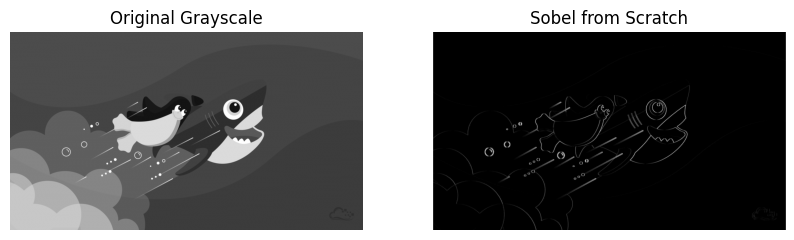

In [30]:
apply_sobel_scratch(penguin_cv2,sobel)

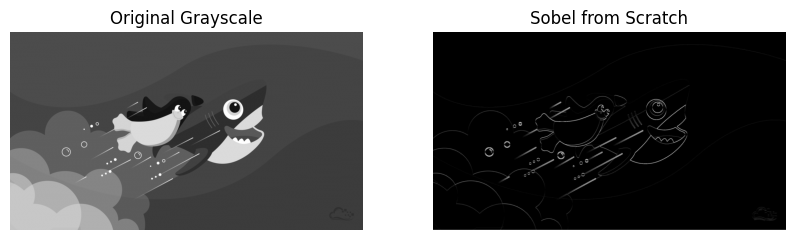

In [31]:
apply_sobel_scratch(penguin_cv2,sobel.T)